# Photoplethysmogram (PPG) heart beat estimation model

## 1. Model building and training

## 1.1. Library import

In [328]:
import pandas as pd
import numpy as np
from scipy.fft import rfft, rfftfreq
import matplotlib.pyplot as plt
import math # sqrt for magnitude
from scipy import signal
%matplotlib inline
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import heartpy as hp
import sklearn
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
import pickle
# from keras.wrappers.scikit_learn import KerasRegressor

## 1.2. Loading csv

In [332]:
all_subjects_csv = pd.read_csv("../Subjects/subjects_csv/all_subjects.csv")
all_subjects_csv

,Subject,0,1,2,3,4,5,6,7,8,...,1303,1304,1305,1306,1307,1308,1309,1310,1311,1312
0,Subject 1,7.28,6.33,5.46,4.60,3.74,2.86,2.03,1.27,0.57,...,32.15,32.15,32.13,32.13,32.13,32.13,32.15,32.15,32.15,49.611369
1,Subject 1,6.34,9.78,12.97,15.82,18.17,19.99,21.33,22.39,23.37,...,32.15,32.15,32.16,32.16,32.16,32.16,32.15,32.15,32.15,50.323992
2,Subject 1,7.70,6.02,4.23,2.46,0.74,-0.93,-2.62,-4.36,-6.16,...,32.15,32.15,32.15,32.15,32.15,32.15,32.13,32.13,32.13,52.708336
3,Subject 1,-120.35,-108.51,-98.97,-91.45,-84.97,-78.29,-70.36,-60.68,-49.41,...,32.13,32.13,32.15,32.15,32.15,32.15,32.13,32.13,32.13,55.640794
4,Subject 1,-7.06,-10.67,-14.96,-19.60,-24.25,-28.65,-32.73,-36.59,-40.43,...,32.13,32.13,32.13,32.13,32.13,32.13,32.15,32.15,32.15,57.658406
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64742,Subject 15,24.22,23.34,22.43,21.48,20.36,19.04,17.55,16.05,14.67,...,34.00,33.99,33.99,33.99,33.99,33.99,33.99,33.99,33.99,80.853007
64743,Subject 15,-35.83,-38.20,-39.20,-38.33,-35.31,-30.30,-23.76,-16.46,-9.23,...,33.99,33.99,33.99,33.99,33.99,NaN,NaN,NaN,NaN,NaN
64744,Subject 15,2.07,1.52,0.42,-0.96,-2.35,-3.55,-4.53,-5.45,-6.52,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64745,Subject 15,15.63,14.74,13.91,12.97,11.83,10.51,9.09,7.69,6.43,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1.3. Data preprocessing functions

In [179]:
def magnitude(x, y, z):
    sq = math.sqrt(x**2 + y**2 + z**2)
    return sq

In [16]:
## Filtering 
def filter_ppg_testing(segment_ppg_full, segment_acc_values):
    """
    Filter the ppg data using a lowpass filter with a 4 Hz cut off frequency and factoring by 0.6.
    Return the ppg cleaned numpy array.

    segment_ppg_full = ppg numpy array that gets cleaned
    segment_acc_values = accelerometer numpy array 
    """
    acc_first_seg_vector = [] # variable that holds the accelerometer vector sum (x + y + z)
    for vector in range(0, len(segment_acc_values), 3):
        acc_first_seg_vector.append(magnitude(segment_acc_values.iloc[vector], segment_acc_values.iloc[vector + 1],segment_acc_values.iloc[vector + 2])) # this is the three channels into one
        
    x_acc_mean = np.mean(acc_first_seg_vector) # mean
    x_acc_std = np.std(acc_first_seg_vector) # standard deviation
    x_acc_normalized = (acc_first_seg_vector - x_acc_mean) / x_acc_std # z normalisation

    segment_ppg_full_mean = np.mean(segment_ppg_full) # mean
    segment_ppg_full_std = np.std(segment_ppg_full) # standard deviation
    segment_ppg_full_normalized = (segment_ppg_full - segment_ppg_full_mean) / segment_ppg_full_std # z normalisation
    
    x_acc_downsampled = signal.resample(x_acc_normalized, len(segment_ppg_full))
    
    isolated_ppg = (segment_ppg_full_normalized - (x_acc_downsampled*0.6)) * 0.6
    ppg_cleaned = hp.filter_signal(isolated_ppg, cutoff = 4, sample_rate = 64.0, order = 5, filtertype='lowpass')
    # plt.figure(figsize=(20,10))
    # plt.plot(ppg_cleaned, linewidth=2 ,label=f'{0.6}')
    # plt.plot(x_acc, x_acc_normalized, label='raw magnitude')
    # plt.legend()
    # plt.show()
    return ppg_cleaned

In [110]:
def full_channels_2d_arr_segment_testing(dataset, index):
    """
    Retrieve the values from the single channel of the PPG and the three-axis channels of the accelerometer, apply rFFT and z-normalisation on them. 
    Return the 2d numpy array (Nch x Nfft). 
    
    Nch = number of channels (1 -> PPG + 3 -> accelerometer axis x,y,z)
    Nfft = number of rFFT points
    
    Parameters:
    dataset = subject dataframe
    index = index of the 8-second segment
    """
    ## RETRIEVING THE SENSORS VALUES FROM THE DATAFRAME
    segment_ppg_full = []
    segment_label = dataset.iloc[index, -1]
    segment_ppg_values = dataset.iloc[index, 43:514]
    second_seg_ppg = dataset.iloc[index+1, 2:43]
    segment_acc_values = dataset.iloc[index, 514:1282]

    segment_ppg_full = np.concatenate([segment_ppg_values, second_seg_ppg])
    
    ppg_cleaned = filter_ppg_testing(segment_ppg_full, segment_acc_values)
    
    ## GETTING THE ACCELEROMETER AXIS
    acc_first_seg_vector_x = [] # variable that holds the accelerometer vector x
    acc_first_seg_vector_y = [] # variable that holds the accelerometer vector y
    acc_first_seg_vector_z = [] # variable that holds the accelerometer vector z
    for vector in range(0, len(segment_acc_values), 3):
        acc_first_seg_vector_x.append(segment_acc_values.iloc[vector])
        acc_first_seg_vector_y.append(segment_acc_values.iloc[vector+1])
        acc_first_seg_vector_z.append(segment_acc_values.iloc[vector+2])
        
    ppg_downsampled = signal.resample(ppg_cleaned, len(acc_first_seg_vector_x)) # The resample function uses interpolation techniques to estimate the missing values introduced during downsampling
    
    ## ACCELEROMETER X FFT AND FILTERING TO 4 HZ
    SAMPLE_RATE = 32  # Hertz, sampling rate of the acc sensor
    DURATION = 8  # Seconds that we segmented
    N = len(acc_first_seg_vector_x) # number of samples in 8 seconds
    acc_first_seg_vector_rfft_x = rfft(acc_first_seg_vector_x)
    acc_first_seg_vector_rfftfreq_x = rfftfreq(N, 1/SAMPLE_RATE)
    
    df_acc_seg_rfft_x = pd.DataFrame({'frequency': acc_first_seg_vector_rfftfreq_x, 'movement': acc_first_seg_vector_rfft_x}) # creating a new df for the rFFT

    df_acc_seg_rfft_filtered_x = df_acc_seg_rfft_x[df_acc_seg_rfft_x['frequency'] <= 4] # filtering the spectrum to only the frequency range 0-4 Hz
    
    freq_acc_seg_arr_x = np.array(df_acc_seg_rfft_filtered_x['frequency'])
    df_acc_seg_arr_x = np.array(df_acc_seg_rfft_filtered_x['movement'])
    df_acc_seg_arr_x_new_arr = []
    for i in range(0,len(df_acc_seg_arr_x)): # get rid of the imaginary part and increment it as a real number
        df_acc_seg_arr_x_new_arr.append(df_acc_seg_arr_x[i].real)
        df_acc_seg_arr_x_new_arr.append(df_acc_seg_arr_x[i].imag)
    df_acc_seg_arr_x = np.array(df_acc_seg_arr_x_new_arr)
    # acc_seg_irfft_x = irfft(df_acc_seg_arr_x)

    ## ACCELEROMETER Y FFT AND FILTERING TO 4 HZ
    acc_first_seg_vector_rfft_y = rfft(acc_first_seg_vector_y)
    acc_first_seg_vector_rfftfreq_y = rfftfreq(N, 1/SAMPLE_RATE)
    
    df_acc_seg_rfft_y = pd.DataFrame({'frequency': acc_first_seg_vector_rfftfreq_y, 'movement': acc_first_seg_vector_rfft_y}) # creating a new df for the rFFT

    df_acc_seg_rfft_filtered_y = df_acc_seg_rfft_y[df_acc_seg_rfft_y['frequency'] <= 4] # filtering the spectrum to only the frequency range 0-4 Hz
    
    freq_acc_seg_arr_y = np.array(df_acc_seg_rfft_filtered_y['frequency'])
    df_acc_seg_arr_y = np.array(df_acc_seg_rfft_filtered_y['movement'])
    df_acc_seg_arr_y_new_arr = [] 
    for i in range(0,len(df_acc_seg_arr_y)): # get rid of the imaginary part and increment it as a real number
        df_acc_seg_arr_y_new_arr.append(df_acc_seg_arr_y[i].real)
        df_acc_seg_arr_y_new_arr.append(df_acc_seg_arr_y[i].imag)
    df_acc_seg_arr_y = np.array(df_acc_seg_arr_y_new_arr)
    # print(df_acc_seg_arr_y)
    # acc_seg_irfft_y = irfft(df_acc_seg_arr_y)
    
    ## ACCELEROMETER Z FFT AND FILTERING TO 4 HZ
    acc_first_seg_vector_rfft_z = rfft(acc_first_seg_vector_z)
    acc_first_seg_vector_rfftfreq_z = rfftfreq(N, 1/SAMPLE_RATE)
    
    df_acc_seg_rfft_z = pd.DataFrame({'frequency': acc_first_seg_vector_rfftfreq_z, 'movement': acc_first_seg_vector_rfft_z}) # creating a new df for the rFFT

    df_acc_seg_rfft_filtered_z = df_acc_seg_rfft_z[df_acc_seg_rfft_z['frequency'] <= 4] # filtering the spectrum to only the frequency range 0-4 Hz
    
    freq_acc_seg_arr_z = np.array(df_acc_seg_rfft_filtered_z['frequency'])
    df_acc_seg_arr_z = np.array(df_acc_seg_rfft_filtered_z['movement'])
    df_acc_seg_arr_z_new_arr = [] 
    for i in range(0,len(df_acc_seg_arr_z)): # get rid of the imaginary part and increment it as a real number
        df_acc_seg_arr_z_new_arr.append(df_acc_seg_arr_z[i].real)
        df_acc_seg_arr_z_new_arr.append(df_acc_seg_arr_z[i].imag)
    df_acc_seg_arr_z = np.array(df_acc_seg_arr_z_new_arr)
    
    ## PPG FFT AND FILTERING TO 4 HZ
    SAMPLE_RATE = 64  # Hertz, sampling rate of the ppg sensor
    DURATION = 8  # Seconds that we segmented
    N = len(ppg_cleaned) # number of samples in 8 seconds
    ppg_seg_vector_rfft = rfft(ppg_cleaned)
    ppg_seg_vector_rfftfreq = rfftfreq(N, 1/SAMPLE_RATE)
    
    df_ppg_seg_rfft = pd.DataFrame({'frequency': ppg_seg_vector_rfftfreq, 'heartrate': ppg_seg_vector_rfft}) # creating a new df for the rFFT

    df_ppg_seg_rfft_filtered = df_ppg_seg_rfft[df_ppg_seg_rfft['frequency'] <= 4] # filtering the spectrum to only the frequency range 0-4 Hz

    freq_ppg_seg_arr = np.array(df_ppg_seg_rfft_filtered['frequency'])
    df_ppg_seg_arr = np.array(df_ppg_seg_rfft_filtered['heartrate'])
    df_ppg_seg_arr_new_arr = [] 
    for i in range(0,len(df_ppg_seg_arr)): # get rid of the imaginary part and increment it as a real number
        df_ppg_seg_arr_new_arr.append(df_ppg_seg_arr[i].real)
        df_ppg_seg_arr_new_arr.append(df_ppg_seg_arr[i].imag)
    df_ppg_seg_arr = np.array(df_ppg_seg_arr_new_arr)
    # ppg_seg_irfft = irfft(df_ppg_seg_arr)
    
    # ACCELEROMETER X NORMALISATION ON THE FFT
    acc_rfft_mean_x = np.mean(df_acc_seg_arr_x) # mean
    acc_rfft_std_x = np.std(df_acc_seg_arr_x) # standard deviation
    acc_rfft_normalized_x = (df_acc_seg_arr_x - acc_rfft_mean_x) / acc_rfft_std_x # z normalisation
    
    ## ACCELEROMETER Y NORMALISATION ON THE FFT
    acc_rfft_mean_y = np.mean(df_acc_seg_arr_y) # mean
    acc_rfft_std_y = np.std(df_acc_seg_arr_y) # standard deviation
    acc_rfft_normalized_y = (df_acc_seg_arr_y - acc_rfft_mean_y) / acc_rfft_std_y # z normalisation
    
    ## ACCELEROMETER Z NORMALISATION ON THE FFT
    acc_rfft_mean_z = np.mean(df_acc_seg_arr_z) # mean
    acc_rfft_std_z = np.std(df_acc_seg_arr_z) # standard deviation
    acc_rfft_normalized_z = (df_acc_seg_arr_z - acc_rfft_mean_z) / acc_rfft_std_z # z normalisation

    ## PPG NORMALISATION ON THE FFT
    ppg_rfft_mean = np.mean(df_ppg_seg_arr) # mean
    ppg_rfft_std = np.std(df_ppg_seg_arr) # standard deviation
    ppg_rfft_normalized = (df_ppg_seg_arr - ppg_rfft_mean) / ppg_rfft_std # z normalisation
            
    # print(len(ppg_rfft_normalized),len(x_acc_downsampled),len(y_acc_downsampled),len(z_acc_downsampled))

    # CREATING THE 2D ARRAY CONTAINING THE FFT VALUES OF EACH CHANNEL PER FREQUENCY
    full_channel_2d_arr = np.array([ppg_rfft_normalized, acc_rfft_normalized_x, acc_rfft_normalized_y, acc_rfft_normalized_z])
    full_channel_2d_arr = np.reshape(full_channel_2d_arr,(66,4))
    # print(full_channel_2d_arr.shape)
    return full_channel_2d_arr
test_ = full_channels_2d_arr_segment_testing(all_subjects_csv, 0)

In [18]:
def get_labels_testing(dataset, index):
    """
    Get the label data point of the index and return it. 
    
    Parameters:
    dataset = subject dataframe
    index = index of the 8-second segment
    """
    ## RETRIEVING THE SENSORS VALUES FROM THE DATAFRAME
    segment_label = dataset.iloc[index, -1]
    return segment_label

In [118]:
def range_inclusive(first_index, last_index): # Helper function
    return range(first_index, last_index+1)

def get_subject_segments_testing(dataset, first_index=0, last_index=4000):
    """
    Pull the N-indexes of the specific subject and return the 3d numpy array (Ntr x Nch x Nfft).

    Ntr = number of segments used together for heart rate estimation
    Nch = number of channels (1 -> PPG + 3 -> accelerometer axis x,y,z)
    Nfft = number of rFFT points
    
    Parameters:
    dataset = subject dataframe
    first_index = first segment index 
    last_index = last segment index to
    """
    if(first_index <= last_index):
        input_list = []
        for index in range_inclusive(first_index, last_index):
            input_list.append(full_channels_2d_arr_segment_testing(all_subjects_csv, index))
        full_channels_3d_arr = np.stack(input_list, axis=0)
        # print(full_channels_3d_arr)
        return full_channels_3d_arr
    else:
        print("It should be an increment order")
        return None

In [144]:
def get_labels_segments_testing(dataset, first_index=0, last_index=4000):
    """
    Get the label data points from the index range and return it as a numpy array.
    
    Parameters:
    dataset = subject dataframe
    first_index = first segment index 
    last_index = last segment index to
    """
    if(first_index <= last_index):
        labels_list = []
        for index in range_inclusive(first_index, last_index):
            labels_list.append(get_labels_testing(dataset, index))
        return np.array(labels_list)
    else:
        print("It should be an increment order")
        return None

In [21]:
def plot_loss_curves(history):
    """
    Returns separate loss curves for training and validation metrics.
    """ 
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    mae = history.history['mae']
    val_mae = history.history['val_mae']

    epochs = range(len(history.history['loss']))

    # Plot loss
    plt.plot(epochs, loss, label='training_loss')
    plt.plot(epochs, val_loss, label='val_loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()

    # Plot accuracy
    plt.figure()
    plt.plot(epochs, mae, label='training_mae')
    plt.plot(epochs, val_mae, label='val_mae')
    plt.title('MAE')
    plt.xlabel('Epochs')
    plt.legend();


In [22]:
def plot_predictions(train_data, 
                     train_labels, 
                     test_data, 
                     test_labels, 
                     predictions):
    """
    Plots training data, test data and compares predictions.
    """
    plt.figure(figsize=(10, 7))
    # Plot training data in blue
    plt.plot(train_data, train_labels, label="Training data")
    # Plot test data in green
    plt.plot(test_data, test_labels, label="Testing data")
    # Plot the predictions in red (predictions were made on the test data)
    plt.plot(test_data, predictions, label="Predictions")
    # Show the legend
    plt.legend();

In [23]:
def separate_subjects(dataframe):
    unique_subjects = dataframe['Subject'].unique()

    subject_dataframes = {}

    for subject in unique_subjects:
        subject_df = dataframe[dataframe['Subject'] == subject].reset_index(drop=True)
        subject_dataframes[subject] = subject_df

    return subject_dataframes

## 1.4. Getting the data

In [140]:
# len(subject_dataframes['Subject 1'])
subject_dataframes = separate_subjects(all_subjects_csv)
# train_data_testing = get_subject_segments_testing(subject_dataframes['Subject 4'], 0, 10)
# test_data_testing = get_subject_segments_testing(subject_dataframes['Subject 7'], 0, 10)
# print(train_data_testing.shape, test_data_testing.shape)
# train_labels_testing = get_labels_segments_testing(subject_dataframes['Subject 1'], 0, 10)
# test_labels_testing = get_labels_segments_testing(subject_dataframes['Subject 7'], 0, 10)
# print(len(train_labels_testing), len(test_labels_testing))

In [142]:
subject_dataframes['Subject 1']

,Subject,0,1,2,3,4,5,6,7,8,...,1303,1304,1305,1306,1307,1308,1309,1310,1311,1312
0,Subject 1,7.28,6.33,5.46,4.60,3.74,2.86,2.03,1.27,0.57,...,32.15,32.15,32.13,32.13,32.13,32.13,32.15,32.15,32.15,49.611369
1,Subject 1,6.34,9.78,12.97,15.82,18.17,19.99,21.33,22.39,23.37,...,32.15,32.15,32.16,32.16,32.16,32.16,32.15,32.15,32.15,50.323992
2,Subject 1,7.70,6.02,4.23,2.46,0.74,-0.93,-2.62,-4.36,-6.16,...,32.15,32.15,32.15,32.15,32.15,32.15,32.13,32.13,32.13,52.708336
3,Subject 1,-120.35,-108.51,-98.97,-91.45,-84.97,-78.29,-70.36,-60.68,-49.41,...,32.13,32.13,32.15,32.15,32.15,32.15,32.13,32.13,32.13,55.640794
4,Subject 1,-7.06,-10.67,-14.96,-19.60,-24.25,-28.65,-32.73,-36.59,-40.43,...,32.13,32.13,32.13,32.13,32.13,32.13,32.15,32.15,32.15,57.658406
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4601,Subject 1,-155.18,-144.64,-125.15,-95.72,-56.65,-9.83,41.36,92.59,139.57,...,34.37,34.37,34.37,34.37,34.37,34.37,34.37,34.37,34.37,85.796257
4602,Subject 1,-25.97,-16.65,-5.75,6.15,18.02,28.44,35.91,39.13,37.35,...,34.37,34.37,34.37,34.37,34.37,34.37,34.37,34.37,34.37,87.411399
4603,Subject 1,-237.02,-227.49,-195.61,-150.52,-104.02,-63.90,-32.88,-10.44,5.46,...,34.37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4604,Subject 1,181.48,193.18,200.83,203.83,201.72,194.29,181.52,157.57,131.74,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1.5. Model creation

In [87]:
# model with 11 Ntr, nfc= 512, epochs = 100 and batch_size = 128 with different subjects (4 for training and 7 for testing) and MSE for loss
model_1 = models.Sequential()
model_1.add(layers.Conv2D(filters=8, kernel_size=(1,1), strides=(1, 1), activation='elu', input_shape=(66, 4, 1),padding='same'))
model_1.add(layers.Conv2D(filters=16, kernel_size=(16,3), strides=(1, 1), activation='elu', input_shape=(66, 4, 1)))
model_1.add(layers.MaxPooling2D(pool_size=(1, 2),strides=(1,2)))
for Nl in range(1,8):
    model_1.add(layers.Conv2D(filters= pow(2, Nl+4), kernel_size=(1,3), strides=(1, 1), activation='elu', padding='same'))
    model_1.add(layers.MaxPooling2D(pool_size=(1, 2),strides=(1,2), padding='same'))
model_1.add(layers.Conv2D(filters=32, kernel_size=(1,1), strides=(1, 1), activation='elu'))

model_1.add(layers.Flatten())
model_1.add(layers.Dense(512, activation='elu'))
model_1.add(layers.Dropout(rate=0.5))
model_1.add(layers.Dense(1, activation='linear'))
# model.summary()
model_1.compile(optimizer='adam',
      loss=tf.keras.losses.MeanSquaredError(),
             metrics=["mae"])

history = model_1.fit(train_data_testing, train_labels_testing, epochs=100, batch_size = 128, 
                    validation_data=(test_data_testing, test_labels_testing))

Epoch 1/100
1/1 [==============================] - 2s 2s/step - loss: 3472.1482 - mae: 58.5563 - val_loss: 3415.9666 - val_mae: 58.0752
Epoch 2/100
1/1 [==============================] - 0s 360ms/step - loss: 3416.0588 - mae: 58.0744 - val_loss: 2971.2708 - val_mae: 54.1187
Epoch 3/100
1/1 [==============================] - 0s 375ms/step - loss: 2977.9634 - mae: 54.1665 - val_loss: 1666.1202 - val_mae: 40.3223
Epoch 4/100
1/1 [==============================] - 0s 431ms/step - loss: 1693.1294 - mae: 40.6783 - val_loss: 53.0790 - val_mae: 5.5195
Epoch 5/100
1/1 [==============================] - 0s 436ms/step - loss: 68.8254 - mae: 5.8600 - val_loss: 5078.9722 - val_mae: 71.0718
Epoch 6/100
1/1 [==============================] - 0s 388ms/step - loss: 4621.3628 - mae: 67.4416 - val_loss: 345.7325 - val_mae: 17.7231
Epoch 7/100
1/1 [==============================] - 0s 366ms/step - loss: 348.3385 - mae: 16.6223 - val_loss: 222.6355 - val_mae: 13.6553
Epoch 8/100
1/1 [======================

In [70]:
scores = model.evaluate(test_data_testing, test_labels_testing, batch_size=128)
y_preds = model.predict(test_data_testing)

1/1 [==============================] - 0s 180ms/step


In [71]:
scores

[3.0400238037109375, 1.4440900087356567]

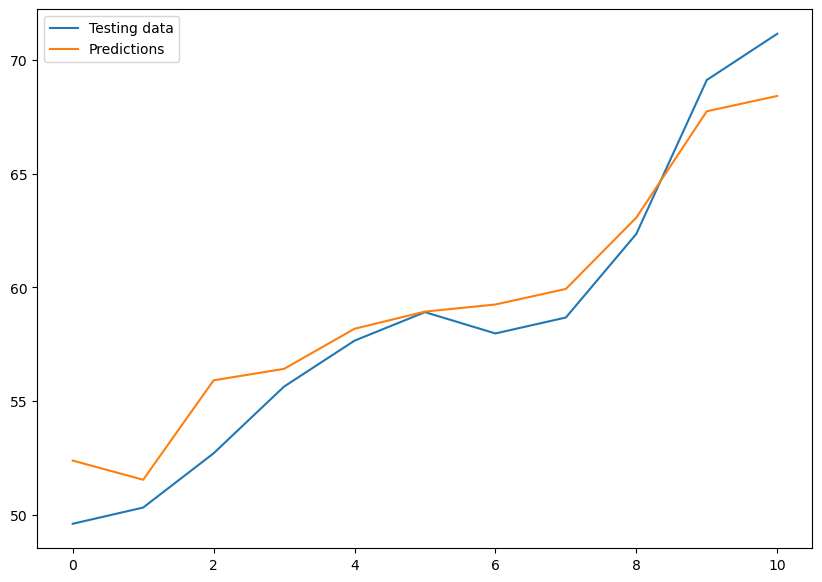

In [74]:
plt.figure(figsize=(10, 7))
plt.plot(test_labels_testing, label="Testing data")
plt.plot(y_preds, label="Predictions")
# Show the legend
plt.legend();

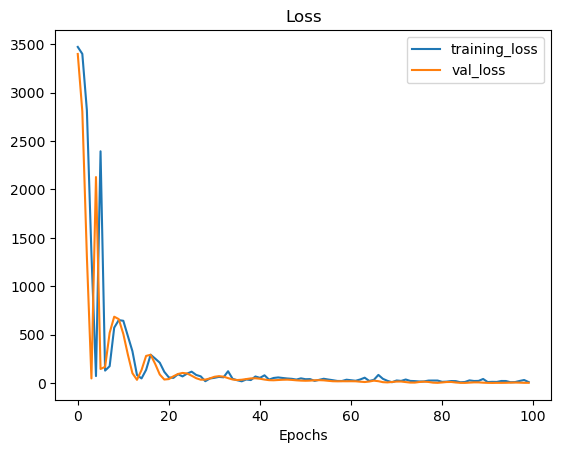

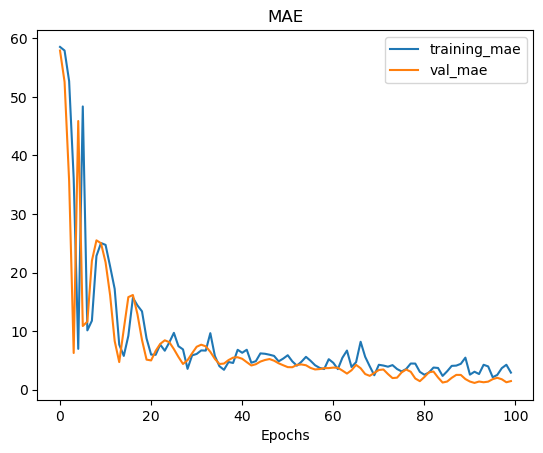

In [76]:
plot_loss_curves(history)

In [89]:
# model with 8 Ntr (subject 4 as training and subject 7 as testing), nfc= 512, epochs = 100 and batch_size = 128 and MAE for loss
subject_dataframes = separate_subjects(all_subjects_csv)
train_data_testing = get_subject_segments_testing(subject_dataframes['Subject 4'], 0, 7)
test_data_testing = get_subject_segments_testing(subject_dataframes['Subject 7'], 0, 7)
train_labels_testing = get_labels_segments_testing(subject_dataframes['Subject 1'], 0, 7)
test_labels_testing = get_labels_segments_testing(subject_dataframes['Subject 7'], 0, 7)

model = models.Sequential()
model.add(layers.Conv2D(filters=8, kernel_size=(1,1), strides=(1, 1), activation='elu', input_shape=(66, 4, 1),padding='same'))
model.add(layers.Conv2D(filters=16, kernel_size=(16,3), strides=(1, 1), activation='elu', input_shape=(66, 4, 1)))
model.add(layers.MaxPooling2D(pool_size=(1, 2),strides=(1,2)))
for Nl in range(1,8):
    model.add(layers.Conv2D(filters= pow(2, Nl+4), kernel_size=(1,3), strides=(1, 1), activation='elu', padding='same'))
    model.add(layers.MaxPooling2D(pool_size=(1, 2),strides=(1,2), padding='same'))
model.add(layers.Conv2D(filters=32, kernel_size=(1,1), strides=(1, 1), activation='elu'))
model.add(layers.Flatten())
model.add(layers.Dense(512, activation='elu'))
model.add(layers.Dropout(rate=0.5))
model.add(layers.Dense(1, activation='linear'))
# model.summary()
model.compile(optimizer='adam',
      loss=tf.keras.losses.MeanAbsoluteError())

history = model.fit(train_data_testing, train_labels_testing, epochs=100, batch_size = 128, 
                    validation_data=(test_data_testing, test_labels_testing))

Epoch 1/100
1/1 [==============================] - 2s 2s/step - loss: 55.1822 - val_loss: 54.4484
Epoch 2/100
1/1 [==============================] - 0s 373ms/step - loss: 54.4223 - val_loss: 49.6329
Epoch 3/100
1/1 [==============================] - 0s 362ms/step - loss: 49.6114 - val_loss: 33.5742
Epoch 4/100
1/1 [==============================] - 0s 349ms/step - loss: 34.5336 - val_loss: 6.4965
Epoch 5/100
1/1 [==============================] - 0s 345ms/step - loss: 8.2764 - val_loss: 10.8909
Epoch 6/100
1/1 [==============================] - 0s 350ms/step - loss: 10.0069 - val_loss: 5.5605
Epoch 7/100
1/1 [==============================] - 0s 334ms/step - loss: 4.3677 - val_loss: 11.3956
Epoch 8/100
1/1 [==============================] - 0s 349ms/step - loss: 13.2919 - val_loss: 4.0677
Epoch 9/100
1/1 [==============================] - 0s 349ms/step - loss: 5.0596 - val_loss: 11.4978
Epoch 10/100
1/1 [==============================] - 0s 312ms/step - loss: 10.9319 - val_loss: 15.597

In [94]:
# model with 8 Ntr (subject 4 as training and subject 7 as testing), nfc= 64, epochs = 100 and batch_size = 128 and MAE for loss
subject_dataframes = separate_subjects(all_subjects_csv)
train_data_testing = get_subject_segments_testing(subject_dataframes['Subject 4'], 0, 7)
test_data_testing = get_subject_segments_testing(subject_dataframes['Subject 7'], 0, 7)
train_labels_testing = get_labels_segments_testing(subject_dataframes['Subject 1'], 0, 7)
test_labels_testing = get_labels_segments_testing(subject_dataframes['Subject 7'], 0, 7)

model = models.Sequential()
model.add(layers.Conv2D(filters=8, kernel_size=(1,1), strides=(1, 1), activation='elu', input_shape=(66, 4, 1),padding='same'))
model.add(layers.Conv2D(filters=16, kernel_size=(16,3), strides=(1, 1), activation='elu', input_shape=(66, 4, 1)))
model.add(layers.MaxPooling2D(pool_size=(1, 2),strides=(1,2)))
for Nl in range(1,8):
    model.add(layers.Conv2D(filters= pow(2, Nl+4), kernel_size=(1,3), strides=(1, 1), activation='elu', padding='same'))
    model.add(layers.MaxPooling2D(pool_size=(1, 2),strides=(1,2), padding='same'))
model.add(layers.Conv2D(filters=32, kernel_size=(1,1), strides=(1, 1), activation='elu'))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='elu'))
model.add(layers.Dropout(rate=0.5))
model.add(layers.Dense(1, activation='linear'))
model.summary()
model.compile(optimizer='adam',
      loss=tf.keras.losses.MeanAbsoluteError())

history = model.fit(train_data_testing, train_labels_testing, epochs=100, batch_size = 128, 
                    validation_data=(test_data_testing, test_labels_testing))

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_50 (Conv2D)          (None, 66, 4, 8)          16        
                                                                 
 conv2d_51 (Conv2D)          (None, 51, 2, 16)         6160      
                                                                 
 max_pooling2d_40 (MaxPooli  (None, 51, 1, 16)         0         
 ng2D)                                                           
                                                                 
 conv2d_52 (Conv2D)          (None, 51, 1, 32)         1568      
                                                                 
 max_pooling2d_41 (MaxPooli  (None, 51, 1, 32)         0         
 ng2D)                                                           
                                                                 
 conv2d_53 (Conv2D)          (None, 51, 1, 64)        

In [545]:
# model with 40001 Ntr, nfc= 512, epochs = 100 and batch_size = 128 with different subjects (4 for training and 7 for testing), MSE for loss and MAE as metrics
subject_dataframes = separate_subjects(all_subjects_csv)
train_data_testing = get_subject_segments_testing(subject_dataframes['Subject 4'], 0, 4000)
test_data_testing = get_subject_segments_testing(subject_dataframes['Subject 7'], 0, 4000)
train_labels_testing = get_labels_segments_testing(subject_dataframes['Subject 1'], 0, 4000)
test_labels_testing = get_labels_segments_testing(subject_dataframes['Subject 7'], 0, 4000)

model_2 = models.Sequential()
model_2.add(layers.Conv2D(filters=8, kernel_size=(1,1), strides=(1, 1), activation='elu', input_shape=(66, 4, 1),padding='same'))
model_2.add(layers.Conv2D(filters=16, kernel_size=(16,3), strides=(1, 1), activation='elu', input_shape=(66, 4, 1)))
model_2.add(layers.MaxPooling2D(pool_size=(1, 2),strides=(1,2)))
for Nl in range(1,8):
    model_2.add(layers.Conv2D(filters= pow(2, Nl+4), kernel_size=(1,3), strides=(1, 1), activation='elu', padding='same'))
    model_2.add(layers.MaxPooling2D(pool_size=(1, 2),strides=(1,2), padding='same'))
model_2.add(layers.Conv2D(filters=32, kernel_size=(1,1), strides=(1, 1), activation='elu'))

model_2.add(layers.Flatten())
model_2.add(layers.Dense(512, activation='elu'))
model_2.add(layers.Dropout(rate=0.5))
model_2.add(layers.Dense(1, activation='linear'))
# model.summary()
model_2.compile(optimizer='adam',
      loss=tf.keras.losses.MeanSquaredError(),
             metrics=["mae"])

history = model_2.fit(train_data_testing_2, train_labels_testing_2, epochs=100, batch_size = 128, 
                    validation_data=(test_data_testing_2, test_labels_testing_2))

Epoch 1/100
32/32 [==============================] - 62s 2s/step - loss: 1153.8491 - mae: 24.1127 - val_loss: 250.7133 - val_mae: 11.6394
Epoch 2/100
32/32 [==============================] - 70s 2s/step - loss: 206.0846 - mae: 10.4400 - val_loss: 171.1604 - val_mae: 9.1746
Epoch 3/100
32/32 [==============================] - 67s 2s/step - loss: 189.8890 - mae: 9.9273 - val_loss: 165.9280 - val_mae: 9.0154
Epoch 4/100
32/32 [==============================] - 66s 2s/step - loss: 187.9070 - mae: 9.8472 - val_loss: 166.3902 - val_mae: 9.1756
Epoch 5/100
32/32 [==============================] - 61s 2s/step - loss: 193.2289 - mae: 10.0549 - val_loss: 175.4634 - val_mae: 9.2727
Epoch 6/100
32/32 [==============================] - 49s 2s/step - loss: 182.4552 - mae: 9.7376 - val_loss: 153.5187 - val_mae: 8.8552
Epoch 7/100
32/32 [==============================] - 48s 1s/step - loss: 170.6310 - mae: 9.4714 - val_loss: 138.1906 - val_mae: 8.1703
Epoch 8/100
32/32 [==============================]

In [567]:
evaluate_data_2 = get_subject_segments_testing(subject_dataframes['Subject 6'], 0, 4000)
evaluate_label_2 = get_labels_segments_testing(subject_dataframes['Subject 6'], 0, 4000)
scores = model_2.evaluate(evaluate_data_2, evaluate_label_2, batch_size=128)
y_preds = model_2.predict(evaluate_data_2)

126/126 [==============================] - 10s 76ms/step


In [549]:
scores

[58.58768081665039, 6.778100967407227]

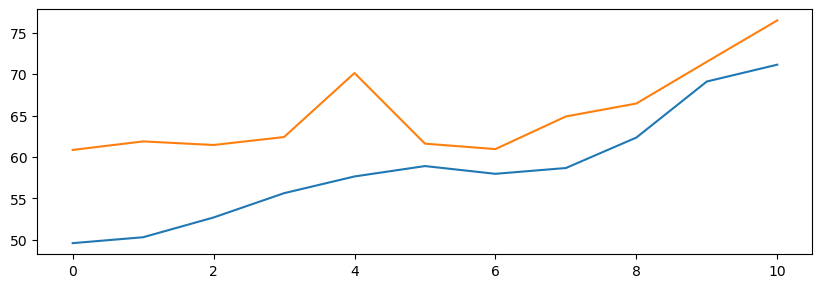

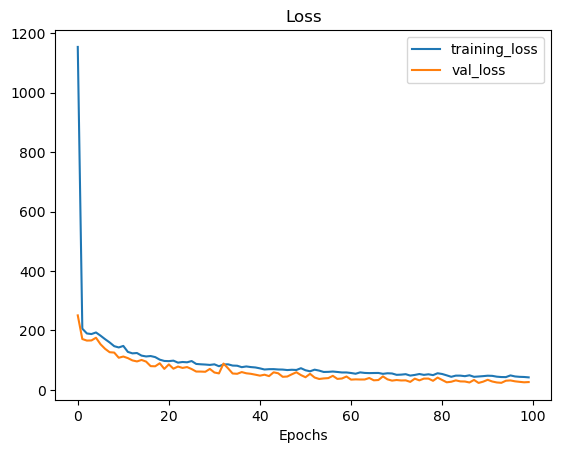

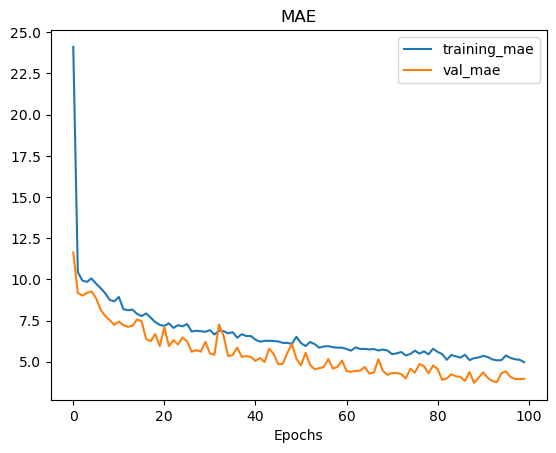

In [565]:
plt.figure(figsize=(10, 7))
plt.subplot(2,1,1)
plt.plot(test_labels_testing, label="Testing data")
plt.plot(y_preds, label="Predictions")
plt.show()
plot_loss_curves(history)
# Show the legend
plt.legend();

## 1.6. K fold cross validation

In [98]:
def k_fold_cross_validation_subjects(subject_dfs):
    k=15
    kfold = KFold(n_splits=k, shuffle=True, random_state=42)
    
    subjects_list = list(subject_dataframes.keys())
        
    for fold, (train_subject_indices, test_subject_indices) in enumerate(kfold.split(subjects_list)):
        train_subjects = [subjects_list[i] for i in range(len(subjects_list)) if i in train_subject_indices]
        test_subjects = [subjects_list[i] for i in range(len(subjects_list)) if i in test_subject_indices]
        
        train_dataframes = [subject_dataframes[subject] for subject in train_subjects]
        test_dataframes = [subject_dataframes[subject] for subject in test_subjects]


        train_df = pd.concat(train_dataframes, ignore_index=True)
        test_df = pd.concat(test_dataframes, ignore_index=True)
        
        print(f"Fold {fold + 1}: Train subjects - {train_subjects}, Test subjects - {test_subjects}")

    return test_df
test_ = k_fold_cross_validation_subjects(subject_dataframes)

Fold 1: Train subjects - ['Subject 1', 'Subject 2', 'Subject 3', 'Subject 4', 'Subject 5', 'Subject 6', 'Subject 7', 'Subject 8', 'Subject 9', 'Subject 11', 'Subject 12', 'Subject 13', 'Subject 14', 'Subject 15'], Test subjects - ['Subject 10']
Fold 2: Train subjects - ['Subject 1', 'Subject 2', 'Subject 3', 'Subject 4', 'Subject 5', 'Subject 6', 'Subject 7', 'Subject 8', 'Subject 9', 'Subject 10', 'Subject 11', 'Subject 13', 'Subject 14', 'Subject 15'], Test subjects - ['Subject 12']
Fold 3: Train subjects - ['Subject 2', 'Subject 3', 'Subject 4', 'Subject 5', 'Subject 6', 'Subject 7', 'Subject 8', 'Subject 9', 'Subject 10', 'Subject 11', 'Subject 12', 'Subject 13', 'Subject 14', 'Subject 15'], Test subjects - ['Subject 1']
Fold 4: Train subjects - ['Subject 1', 'Subject 2', 'Subject 3', 'Subject 4', 'Subject 5', 'Subject 6', 'Subject 7', 'Subject 8', 'Subject 9', 'Subject 10', 'Subject 11', 'Subject 12', 'Subject 13', 'Subject 15'], Test subjects - ['Subject 14']
Fold 5: Train subjec

In [260]:
def k_fold_cross_validation_subjects(subject_dfs):
    k = 3
    kfold = KFold(n_splits=k, shuffle=True, random_state=42)

    subjects_list = list(subject_dfs.keys())
    mae_score = []
    loss_score = []
    
    for fold, (train_subject_indices, test_subject_indices) in enumerate(kfold.split(subjects_list)):
        train_subjects = [subjects_list[i] for i in train_subject_indices] # get the 14 subjects
        test_subjects = [subjects_list[i] for i in test_subject_indices] # get the left out subject
        
        train_dataframes = [subject_dfs[subject] for subject in train_subjects] # used to concatenate later on
        test_dataframes = [subject_dfs[subject] for subject in test_subjects]
        
        train_df = pd.concat(train_dataframes, ignore_index=True) # concatenate all 14 subjects into one variable
        test_df = pd.concat(test_dataframes, ignore_index=True)
        
        train_labels = get_labels_segments_testing(train_df, 0, 4)
        test_labels = get_labels_segments_testing(test_df, 0, 4)
        train_data = get_subject_segments_testing(train_df, 0, 4)
        test_data = get_subject_segments_testing(test_df, 0, 4)
        
        #         print(f"TRAIN  {fold} with labels: {train_labels.shape}")
        #         print(f"TRAIN  {fold} with data: {train_data.shape}")
        #         print(f"TEST  {fold} with labels: {test_labels.shape}")
        #         print(f"TEST  {fold} with data: {test_data.shape}")
        
        model_2 = models.Sequential()
        model_2.add(layers.Conv2D(filters=8, kernel_size=(1,1), strides=(1, 1), activation='elu', input_shape=(66, 4, 1),padding='same'))
        model_2.add(layers.Conv2D(filters=16, kernel_size=(16,3), strides=(1, 1), activation='elu', input_shape=(66, 4, 1)))
        model_2.add(layers.MaxPooling2D(pool_size=(1, 2),strides=(1,2)))
        for Nl in range(1,8):
            model_2.add(layers.Conv2D(filters= pow(2, Nl+4), kernel_size=(1,3), strides=(1, 1), activation='elu', padding='same'))
            model_2.add(layers.MaxPooling2D(pool_size=(1, 2),strides=(1,2), padding='same'))
        model_2.add(layers.Conv2D(filters=32, kernel_size=(1,1), strides=(1, 1), activation='elu'))

        model_2.add(layers.Flatten())
        model_2.add(layers.Dense(512, activation='elu'))
        model_2.add(layers.Dropout(rate=0.5))
        model_2.add(layers.Dense(1, activation='linear'))
        # model.summary()
        model_2.compile(optimizer='adam',
              loss=tf.keras.losses.MeanSquaredError(),
                     metrics=["mae"])

        history = model_2.fit(train_data, train_labels, epochs=100, batch_size = 128, 
                            validation_data=(test_data, test_labels))
        
        mae_score.append(history.history['mae'])
        loss_score.append(history.history['loss'])

        return mae_score, loss_score
mae_result, loss_result = k_fold_cross_validation_subjects(subject_dataframes)

Epoch 1/100
1/1 [==============================] - 3s 3s/step - loss: 2838.3481 - mae: 53.1875 - val_loss: 2783.3843 - val_mae: 52.6687
Epoch 2/100
1/1 [==============================] - 0s 388ms/step - loss: 2783.8960 - mae: 52.6740 - val_loss: 2339.7124 - val_mae: 48.2770
Epoch 3/100
1/1 [==============================] - 0s 370ms/step - loss: 2325.6072 - mae: 48.1322 - val_loss: 1127.9076 - val_mae: 33.4618
Epoch 4/100
1/1 [==============================] - 0s 354ms/step - loss: 1140.1768 - mae: 33.6449 - val_loss: 21.0988 - val_mae: 3.6945
Epoch 5/100
1/1 [==============================] - 0s 345ms/step - loss: 22.7943 - mae: 3.2049 - val_loss: 2127.4985 - val_mae: 46.0493
Epoch 6/100
1/1 [==============================] - 0s 348ms/step - loss: 2349.1621 - mae: 48.1071 - val_loss: 103.6240 - val_mae: 9.8290
Epoch 7/100
1/1 [==============================] - 0s 357ms/step - loss: 189.4654 - mae: 12.3901 - val_loss: 182.3757 - val_mae: 13.2270
Epoch 8/100
1/1 [=======================

In [282]:
mae_avg = np.mean(mae_result)
loss_avg = np.mean(loss_result)
print(f"Mae average: {mae_avg} and MSE average: {loss_avg}")


Mae average: 7.580190569162369 and MSE average: 178.219474067688


In [30]:
def k_fold_cross_validation_subjects(subject_dfs):
    k = 3
    kfold = KFold(n_splits=k, shuffle=True, random_state=42)

    subjects_list = list(subject_dfs.keys())
    mae_score = []
    loss_score = []
    
    for fold, (train_subject_indices, test_subject_indices) in enumerate(kfold.split(subjects_list)):
        train_subjects = [subjects_list[i] for i in train_subject_indices] # get the 14 subjects
        test_subjects = [subjects_list[i] for i in test_subject_indices] # get the left out subject
        
        train_dataframes = [subject_dfs[subject] for subject in train_subjects] # used to concatenate later on
        test_dataframes = [subject_dfs[subject] for subject in test_subjects]
        
        train_df = pd.concat(train_dataframes, ignore_index=True) # concatenate all 14 subjects into one variable
        test_df = pd.concat(test_dataframes, ignore_index=True)
        
        train_labels = get_labels_segments_testing(train_df, 0, 4000)
        test_labels = get_labels_segments_testing(test_df, 0, 4000)
        train_data = get_subject_segments_testing(train_df, 0, 4000)
        test_data = get_subject_segments_testing(test_df, 0, 4000)
        
        #         print(f"TRAIN  {fold} with labels: {train_labels.shape}")
        #         print(f"TRAIN  {fold} with data: {train_data.shape}")
        #         print(f"TEST  {fold} with labels: {test_labels.shape}")
        #         print(f"TEST  {fold} with data: {test_data.shape}")
        
        model_2 = models.Sequential()
        model_2.add(layers.Conv2D(filters=8, kernel_size=(1,1), strides=(1, 1), activation='elu', input_shape=(66, 4, 1),padding='same'))
        model_2.add(layers.Conv2D(filters=16, kernel_size=(16,3), strides=(1, 1), activation='elu', input_shape=(66, 4, 1)))
        model_2.add(layers.MaxPooling2D(pool_size=(1, 2),strides=(1,2)))
        for Nl in range(1,8):
            model_2.add(layers.Conv2D(filters= pow(2, Nl+4), kernel_size=(1,3), strides=(1, 1), activation='elu', padding='same'))
            model_2.add(layers.MaxPooling2D(pool_size=(1, 2),strides=(1,2), padding='same'))
        model_2.add(layers.Conv2D(filters=32, kernel_size=(1,1), strides=(1, 1), activation='elu'))

        model_2.add(layers.Flatten())
        model_2.add(layers.Dense(512, activation='elu'))
        model_2.add(layers.Dropout(rate=0.5))
        model_2.add(layers.Dense(1, activation='linear'))
        # model.summary()
        model_2.compile(optimizer='adam',
              loss=tf.keras.losses.MeanSquaredError(),
                     metrics=["mae"])

        history = model_2.fit(train_data, train_labels, epochs=100, batch_size = 128, 
                            validation_data=(test_data, test_labels))
        
        mae_score.append(history.history['mae'])
        loss_score.append(history.history['loss'])

        return mae_score, loss_score
mae_result, loss_result = k_fold_cross_validation_subjects(subject_dataframes)




Epoch 1/100


32/32 [==============================] - 62s 2s/step - loss: 2084.3728 - mae: 37.1235 - val_loss: 487.2751 - val_mae: 16.5765
Epoch 2/100
32/32 [==============================] - 65s 2s/step - loss: 345.5354 - mae: 13.8107 - val_loss: 232.8872 - val_mae: 10.9806
Epoch 3/100
32/32 [==============================] - 60s 2s/step - loss: 213.7988 - mae: 10.6262 - val_loss: 173.7064 - val_mae: 9.0501
Epoch 4/100
32/32 [==============================] - 63s 2s/step - loss: 195.1445 - mae: 10.0176 - val_loss: 168.7006 - val_mae: 9.0309
Epoch 5/100
32/32 [==============================] - 60s 2s/step - loss: 186.2212 - mae: 9.7815 - val_loss: 164.8074 - val_mae: 8.9373
Epoch 6/100
32/32 [==============================] - 62s 2s/step - loss: 178.7138 - mae: 9.5251 - val_loss: 163.6967 - val_mae: 9.0897
Epoch 7/100
32/32 [==============================] - 61s 2s/step - loss: 177.1433 - mae: 9.5548 - val_loss: 151.0005 - val_mae: 8.4092
Epoch 8/100
32/32 [========================

In [33]:
mae_avg = np.mean(mae_result)
loss_avg = np.mean(loss_result)
print(f"Mae average: {mae_avg} and MSE average: {loss_avg}")


Mae average: 6.989201316833496 and MSE average: 105.29019680023194


In [37]:
def k_fold_cross_validation_subjects(subject_dfs):
    k = 15
    kfold = KFold(n_splits=k, shuffle=True, random_state=42)

    subjects_list = list(subject_dfs.keys())
    mae_score = []
    loss_score = []
    
    for fold, (train_subject_indices, test_subject_indices) in enumerate(kfold.split(subjects_list)):
        train_subjects = [subjects_list[i] for i in train_subject_indices] # get the 14 subjects
        test_subjects = [subjects_list[i] for i in test_subject_indices] # get the left out subject
        
        train_dataframes = [subject_dfs[subject] for subject in train_subjects] # used to concatenate later on
        test_dataframes = [subject_dfs[subject] for subject in test_subjects]
        
        train_df = pd.concat(train_dataframes, ignore_index=True) # concatenate all 14 subjects into one variable
        test_df = pd.concat(test_dataframes, ignore_index=True)
        
        train_labels = get_labels_segments_testing(train_df, 0, 4000)
        test_labels = get_labels_segments_testing(test_df, 0, 4000)
        train_data = get_subject_segments_testing(train_df, 0, 4000)
        test_data = get_subject_segments_testing(test_df, 0, 4000)
        
        #         print(f"TRAIN  {fold} with labels: {train_labels.shape}")
        #         print(f"TRAIN  {fold} with data: {train_data.shape}")
        #         print(f"TEST  {fold} with labels: {test_labels.shape}")
        #         print(f"TEST  {fold} with data: {test_data.shape}")
        
        model_2 = models.Sequential()
        model_2.add(layers.Conv2D(filters=8, kernel_size=(1,1), strides=(1, 1), activation='elu', input_shape=(66, 4, 1),padding='same'))
        model_2.add(layers.Conv2D(filters=16, kernel_size=(16,3), strides=(1, 1), activation='elu', input_shape=(66, 4, 1)))
        model_2.add(layers.MaxPooling2D(pool_size=(1, 2),strides=(1,2)))
        for Nl in range(1,8):
            model_2.add(layers.Conv2D(filters= pow(2, Nl+4), kernel_size=(1,3), strides=(1, 1), activation='elu', padding='same'))
            model_2.add(layers.MaxPooling2D(pool_size=(1, 2),strides=(1,2), padding='same'))
        model_2.add(layers.Conv2D(filters=32, kernel_size=(1,1), strides=(1, 1), activation='elu'))

        model_2.add(layers.Flatten())
        model_2.add(layers.Dense(512, activation='elu'))
        model_2.add(layers.Dropout(rate=0.5))
        model_2.add(layers.Dense(1, activation='linear'))
        # model.summary()
        model_2.compile(optimizer='adam',
              loss=tf.keras.losses.MeanSquaredError(),
                     metrics=["mae"])

        history = model_2.fit(train_data, train_labels, epochs=100, batch_size = 128, 
                            validation_data=(test_data, test_labels))
        
        mae_score.append(history.history['mae'])
        loss_score.append(history.history['loss'])

        return history, mae_score, loss_score
history_result, mae_result, loss_result = k_fold_cross_validation_subjects(subject_dataframes)

Epoch 1/100
32/32 [==============================] - 55s 2s/step - loss: 1828.1685 - mae: 33.3836 - val_loss: 369.5181 - val_mae: 14.2259
Epoch 2/100
32/32 [==============================] - 49s 2s/step - loss: 237.7688 - mae: 11.4495 - val_loss: 181.7790 - val_mae: 9.4833
Epoch 3/100
32/32 [==============================] - 50s 2s/step - loss: 199.1351 - mae: 10.1593 - val_loss: 173.2789 - val_mae: 9.1280
Epoch 4/100
32/32 [==============================] - 53s 2s/step - loss: 188.2272 - mae: 9.9148 - val_loss: 169.7241 - val_mae: 9.0370
Epoch 5/100
32/32 [==============================] - 49s 2s/step - loss: 188.5364 - mae: 9.8450 - val_loss: 166.6470 - val_mae: 8.8875
Epoch 6/100
32/32 [==============================] - 50s 2s/step - loss: 182.0307 - mae: 9.6615 - val_loss: 161.3283 - val_mae: 8.7980
Epoch 7/100
32/32 [==============================] - 48s 2s/step - loss: 178.8946 - mae: 9.5277 - val_loss: 157.0082 - val_mae: 8.9020
Epoch 8/100
32/32 [==============================]

In [33]:
def create_model(subject_dfs):
    """
    Apply k-fold cross validation, create the DL model and return it
    subject_dfs = dataset used
    """
    k = 15
    kfold = KFold(n_splits=k, shuffle=True, random_state=42)

    subjects_list = list(subject_dfs.keys())
    mae_score = []
    loss_score = []
    
    for fold, (train_subject_indices, test_subject_indices) in enumerate(kfold.split(subjects_list)):
        train_subjects = [subjects_list[i] for i in train_subject_indices] # get the 14 subjects
        test_subjects = [subjects_list[i] for i in test_subject_indices] # get the left out subject
        
        train_dataframes = [subject_dfs[subject] for subject in train_subjects] # used to concatenate later on
        test_dataframes = [subject_dfs[subject] for subject in test_subjects]
        
        train_df = pd.concat(train_dataframes, ignore_index=True) # concatenate all 14 subjects into one variable
        test_df = pd.concat(test_dataframes, ignore_index=True)
        
        train_labels = get_labels_segments_testing(train_df, 0, 4000)
        test_labels = get_labels_segments_testing(test_df, 0, 4000)
        train_data = get_subject_segments_testing(train_df, 0, 4000)
        test_data = get_subject_segments_testing(test_df, 0, 4000)
        
        #         print(f"TRAIN  {fold} with labels: {train_labels.shape}")
        #         print(f"TRAIN  {fold} with data: {train_data.shape}")
        #         print(f"TEST  {fold} with labels: {test_labels.shape}")
        #         print(f"TEST  {fold} with data: {test_data.shape}")
        
        model = models.Sequential()
        model.add(layers.Conv2D(filters=8, kernel_size=(1,1), strides=(1, 1), activation='elu', input_shape=(66, 4, 1),padding='same'))
        model.add(layers.Conv2D(filters=16, kernel_size=(16,3), strides=(1, 1), activation='elu', input_shape=(66, 4, 1)))
        model.add(layers.MaxPooling2D(pool_size=(1, 2),strides=(1,2)))
        for Nl in range(1,8):
            model.add(layers.Conv2D(filters= pow(2, Nl+4), kernel_size=(1,3), strides=(1, 1), activation='elu', padding='same'))
            model.add(layers.MaxPooling2D(pool_size=(1, 2),strides=(1,2), padding='same'))
        model.add(layers.Conv2D(filters=32, kernel_size=(1,1), strides=(1, 1), activation='elu'))

        model.add(layers.Flatten())
        model.add(layers.Dense(512, activation='elu'))
        model.add(layers.Dropout(rate=0.5))
        model.add(layers.Dense(1, activation='linear'))
        # model.summary()
        model.compile(optimizer='adam',
              loss=tf.keras.losses.MeanSquaredError(),
                     metrics=["mae"])

        history = model.fit(train_data, train_labels, epochs=100, batch_size = 128, 
                            validation_data=(test_data, test_labels))
        
        mae_score.append(history.history['mae'])
        loss_score.append(history.history['loss'])

        return history, mae_score, loss_score, model
history_result, mae_result, loss_result, model_result = create_model(subject_dataframes)




Epoch 1/100


32/32 [==============================] - 54s 2s/step - loss: 1401.3760 - mae: 27.9942 - val_loss: 237.6732 - val_mae: 11.1128
Epoch 2/100
32/32 [==============================] - 52s 2s/step - loss: 211.6812 - mae: 10.7033 - val_loss: 186.3731 - val_mae: 9.4003
Epoch 3/100
32/32 [==============================] - 51s 2s/step - loss: 198.1683 - mae: 10.1674 - val_loss: 172.2187 - val_mae: 8.9832
Epoch 4/100
32/32 [==============================] - 52s 2s/step - loss: 191.8580 - mae: 9.9508 - val_loss: 162.2737 - val_mae: 8.9095
Epoch 5/100
32/32 [==============================] - 49s 2s/step - loss: 181.8532 - mae: 9.7383 - val_loss: 151.7466 - val_mae: 8.3187
Epoch 6/100
32/32 [==============================] - 47s 1s/step - loss: 167.8477 - mae: 9.1966 - val_loss: 144.2704 - val_mae: 8.0032
Epoch 7/100
32/32 [==============================] - 48s 2s/step - loss: 157.6740 - mae: 9.0776 - val_loss: 127.9695 - val_mae: 7.9319
Epoch 8/100
32/32 [==========================

NameError: name 'history' is not defined

In [45]:
with open('kfold_results.pkl', 'wb') as file:
        results = {
            'history_result': history_result,
            'mae_result': mae_result,
            'loss_result': loss_result,
            'model_result': model_result
        }
        pickle.dump(results, file)

Mae average: 6.8042334365844725 and MSE average: 94.46193992614747


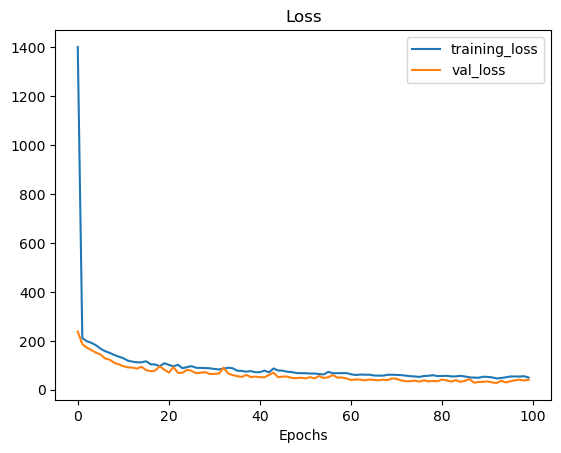

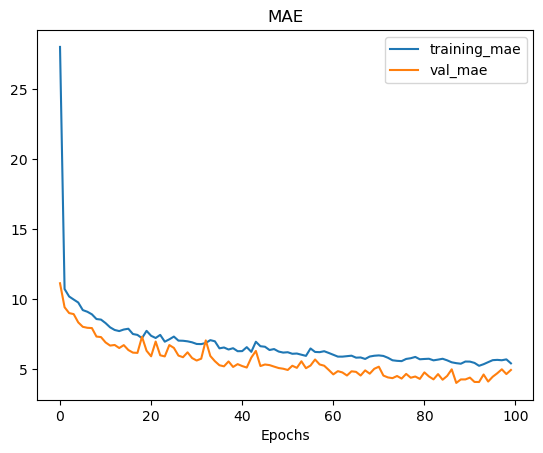

In [47]:
mae_avg = np.mean(mae_result)
loss_avg = np.mean(loss_result)
print(f"Mae average: {mae_avg} and MSE average: {loss_avg}")
plot_loss_curves(history_result)

In [51]:
np.std(mae_result)

2.4205301162254758

## 1.7 Exporting the model

In [37]:
train_subjects = list(subject_dataframes.keys())[:-1]  # Use 14 subjects for training
test_subject = list(subject_dataframes.keys())[-1]  # Use the last subject for testing

train_dataframes = [subject_dataframes[subject] for subject in train_subjects]
test_dataframes = [subject_dataframes[test_subject]]

train_df = pd.concat(train_dataframes, ignore_index=True)
test_df = pd.concat(test_dataframes, ignore_index=True)

train_labels_pipe = get_labels_segments_testing(train_df, 0, 4000)
test_labels_pipe = get_labels_segments_testing(test_df, 0, 4000)
train_data_pipe = get_subject_segments_testing(train_df, 0, 4000)
test_data_pipe = get_subject_segments_testing(test_df, 0, 4000)

In [43]:
from scikeras.wrappers import KerasRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, KFold

# wrap the model using the function you created
clf = KerasRegressor(build_fn=model_result, epochs=100, batch_size=128, verbose=0)

# just create the pipeline
pipeline = Pipeline([
    ('clf',clf)
])

pipeline.fit(train_data_pipe, train_labels_pipe)

C:\Users\silva\anaconda3\Lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Pipeline(steps=[('clf',
                 KerasRegressor(batch_size=128, build_fn=<keras.src.engine.sequential.Sequential object at 0x00000275959E0A10>, epochs=100, verbose=0))])

In [59]:
test_data_pipe = get_subject_segments_testing(test_df, 4, 4)
y_pred2 = pipeline.predict(test_data_pipe)
# ac2 = accuracy_score(test_labels_pipe, y_pred2)
print("Accuracy is :",y_pred2)

Accuracy is : [65.594536]


In [63]:
import pickle
with open('trained_pipeline-0.1.0.pkl','wb') as f:
    pickle.dump(pipeline, f)

INFO:tensorflow:Assets written to: C:\Users\silva\AppData\Local\Temp\tmpnkjhldq7\assets


INFO:tensorflow:Assets written to: C:\Users\silva\AppData\Local\Temp\tmpnkjhldq7\assets


In [33]:
# THIS DOESN'T HAVE KFOLD CROSS VALIDATION, IT JUST GETS THE 14 SUBJECTS AS TRAINING DATA
def create_model(subject_dfs):
    """
    Train the DL model on 14 subjects and test on 1 subject
    subject_dfs = dataset used
    """
    train_subjects = list(subject_dfs.keys())[:-1]  # Use 14 subjects for training
    test_subject = list(subject_dfs.keys())[-1]  # Use the last subject for testing
    
    train_dataframes = [subject_dfs[subject] for subject in train_subjects]
    test_dataframes = [subject_dfs[test_subject]]
    
    train_df = pd.concat(train_dataframes, ignore_index=True)
    test_df = pd.concat(test_dataframes, ignore_index=True)

    train_labels = get_labels_segments_testing(train_df, 0, 4000)
    test_labels = get_labels_segments_testing(test_df, 0, 4000)
    train_data = get_subject_segments_testing(train_df, 0, 4000)
    test_data = get_subject_segments_testing(test_df, 0, 4000)

    model = models.Sequential()
    model.add(layers.Conv2D(filters=8, kernel_size=(1, 1), strides=(1, 1), activation='elu', input_shape=(66, 4, 1), padding='same'))
    model.add(layers.Conv2D(filters=16, kernel_size=(16, 3), strides=(1, 1), activation='elu', input_shape=(66, 4, 1)))
    model.add(layers.MaxPooling2D(pool_size=(1, 2), strides=(1, 2)))
    for Nl in range(1, 8):
        model.add(layers.Conv2D(filters=pow(2, Nl + 4), kernel_size=(1, 3), strides=(1, 1), activation='elu', padding='same'))
        model.add(layers.MaxPooling2D(pool_size=(1, 2), strides=(1, 2), padding='same'))
    model.add(layers.Conv2D(filters=32, kernel_size=(1, 1), strides=(1, 1), activation='elu'))

    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation='elu'))
    model.add(layers.Dropout(rate=0.5))
    model.add(layers.Dense(1, activation='linear'))

    model.compile(optimizer='adam',
                  loss=tf.keras.losses.MeanSquaredError(),
                  metrics=["mae"])

    history = model.fit(train_data, train_labels, epochs=100, batch_size=128,
                        validation_data=(test_data, test_labels))

    return history, model

create_model(subject_dataframes)

train: [        Subject       0       1       2       3       4       5       6  \
0     Subject 1    7.28    6.33    5.46    4.60    3.74    2.86    2.03   
1     Subject 1    6.34    9.78   12.97   15.82   18.17   19.99   21.33   
2     Subject 1    7.70    6.02    4.23    2.46    0.74   -0.93   -2.62   
3     Subject 1 -120.35 -108.51  -98.97  -91.45  -84.97  -78.29  -70.36   
4     Subject 1   -7.06  -10.67  -14.96  -19.60  -24.25  -28.65  -32.73   
...         ...     ...     ...     ...     ...     ...     ...     ...   
4601  Subject 1 -155.18 -144.64 -125.15  -95.72  -56.65   -9.83   41.36   
4602  Subject 1  -25.97  -16.65   -5.75    6.15   18.02   28.44   35.91   
4603  Subject 1 -237.02 -227.49 -195.61 -150.52 -104.02  -63.90  -32.88   
4604  Subject 1  181.48  193.18  200.83  203.83  201.72  194.29  181.52   
4605  Subject 1   34.25   33.24   30.84   27.53   23.72   19.71   15.70   

           7       8  ...   1303   1304   1305   1306   1307   1308   1309  \
0       1.27 

## 1.8. Loading the pickle files

In [31]:
# Loading results pickle file
results_file = open('kfold_results.pkl','rb')

results_data_loaded = pickle.load(results_file)

results_file.close()

In [33]:
# standard deviation of the MAE
np.std(results_data_loaded['mae_result'])

2.4205301162254758

In [45]:
# Loading model pickle file
model_file = open('model_result-0.1.0.pkl','rb')

model_loaded = pickle.load(model_file)

model_file.close()

ModuleNotFoundError: No module named 'keras.src.saving.pickle_utils'

In [122]:
# Loading model pickle file
test_data_loaded_1 = get_subject_segments_testing(subject_dataframes, 0, 0)
test_data_loaded_2 = get_subject_segments_testing(subject_dataframes, 3, 3)
test_data_loaded_3 = get_subject_segments_testing(subject_dataframes, 1256, 1256)
test_data_loaded_4 = get_subject_segments_testing(subject_dataframes, 2579, 2579)

In [55]:
with open('test_data_loaded_1.pkl','wb') as f:
    pickle.dump(test_data_loaded_1, f)
    
with open('test_data_loaded_2.pkl','wb') as f:
    pickle.dump(test_data_loaded_2, f)
    
with open('test_data_loaded_3.pkl','wb') as f:
    pickle.dump(test_data_loaded_3, f)

with open('test_data_loaded_4.pkl','wb') as f:
    pickle.dump(test_data_loaded_4, f)

In [96]:
test_data_pkl_file_1 = open('test_data_loaded_1.pkl','rb')

test_data_pkl_loaded_1 = pickle.load(test_data_pkl_file_1)

test_data_pkl_file_1.close()

test_data_pkl_file_2 = open('test_data_loaded_2.pkl','rb')

test_data_pkl_loaded_2 = pickle.load(test_data_pkl_file_2)

test_data_pkl_file_2.close()

test_data_pkl_file_3 = open('test_data_loaded_3.pkl','rb')

test_data_pkl_loaded_3 = pickle.load(test_data_pkl_file_3)

test_data_pkl_file_3.close()

test_data_pkl_file_4 = open('test_data_loaded_4.pkl','rb')

test_data_pkl_loaded_4 = pickle.load(test_data_pkl_file_4)

test_data_pkl_file_4.close()

In [134]:
test_data_pkl_loaded_1

array([[[ 2.87565620e-01,  2.58450126e-01,  6.31244632e-01,
         -1.79266908e-02],
        [ 3.98696437e-01,  9.60755403e-01, -3.85666420e-01,
         -5.00275814e-01],
        [ 2.28293112e+00,  7.50352079e-01, -1.36322573e+00,
          2.99872614e+00],
        [-2.06257310e+00, -4.31374550e+00,  9.00732530e-01,
          4.50815184e-01],
        [ 5.02089696e-01,  7.49000773e-01, -5.87666642e-01,
          2.30415943e+00],
        [-2.06807940e+00, -9.55468198e-01,  1.69550146e+00,
          5.48755046e-02],
        [-1.28182322e+00,  3.45611077e-01, -3.39415615e-01,
         -9.60816449e-01],
        [ 2.57173236e-01,  1.11891875e+00, -1.17959550e+00,
         -5.32066458e-02],
        [ 4.16193393e-01, -2.41648030e-01, -3.75278165e-01,
          7.87734373e-01],
        [ 2.34556191e-01, -7.83929871e-01,  1.98412718e-01,
          7.23655584e-01],
        [-7.75310287e-01,  2.39541299e-01, -1.62440942e-01,
         -2.52750789e-01],
        [ 6.00060388e-02,  9.15161247e-02, 

In [84]:
model_loaded.predict(test_data_pkl_loaded_2)

1/1 [==============================] - 0s 228ms/step


array([[66.197655]], dtype=float32)

In [81]:
print(tf.__version__)

2.15.0


## 1.9. Hyperparameter tuning

In [314]:
## Filtering 
def magnitude_hyper(x, y, z):
    sq = math.sqrt(x**2 + y**2 + z**2)
    return sq

def filter_ppg_testing_hyper(segment_ppg_full, segment_acc_values):
    """
    Filter the ppg data using a lowpass filter with a 4 Hz cut off frequency and factoring by 0.6.
    Return the ppg cleaned numpy array.

    segment_ppg_full = ppg numpy array that gets cleaned
    segment_acc_values = accelerometer numpy array 
    """
    acc_first_seg_vector = [] # variable that holds the accelerometer vector sum (x + y + z)
    for vector in range(0, len(segment_acc_values), 3):
        acc_first_seg_vector.append(magnitude_hyper(segment_acc_values.iloc[vector], segment_acc_values.iloc[vector + 1],segment_acc_values.iloc[vector + 2])) # this is the three channels into one
        
    x_acc_mean = np.mean(acc_first_seg_vector) # mean
    x_acc_std = np.std(acc_first_seg_vector) # standard deviation
    x_acc_normalized = (acc_first_seg_vector - x_acc_mean) / x_acc_std # z normalisation

    segment_ppg_full_mean = np.mean(segment_ppg_full) # mean
    segment_ppg_full_std = np.std(segment_ppg_full) # standard deviation
    segment_ppg_full_normalized = (segment_ppg_full - segment_ppg_full_mean) / segment_ppg_full_std # z normalisation
    
    # x_acc_downsampled = signal.resample(x_acc_normalized, len(segment_ppg_full))
    
    ppg_downsampled = signal.resample(segment_ppg_full_normalized, len(x_acc_normalized)) # The resample function uses interpolation techniques to estimate the missing values introduced during downsampling

    isolated_ppg = (ppg_downsampled - (x_acc_normalized*0.6)) * 0.6
    ppg_cleaned = hp.filter_signal(isolated_ppg, cutoff = 4, sample_rate = 64.0, order = 5, filtertype='lowpass')
    # plt.figure(figsize=(20,10))
    # plt.plot(ppg_downsampled, linewidth=2 ,label='raw ppg')
    # plt.plot(acc_first_seg_vector_x, linewidth=2 ,label=f'x')
    # plt.plot(acc_first_seg_vector_y, linewidth=2 ,label=f'y')
    # plt.plot(acc_first_seg_vector_z, linewidth=2 ,label=f'z')
    # plt.plot(x_acc_downsampled, label='raw magnitude')
    # plt.ylim((-4,5))
    # plt.legend()
    # plt.show()
    return ppg_cleaned
# segment_ppg_full = []
# segment_label = subject_dataframes['Subject 1'].iloc[0, -1]
# segment_ppg_values = subject_dataframes['Subject 1'].iloc[0, 43:514]
# second_seg_ppg = subject_dataframes['Subject 1'].iloc[0+1, 2:43]
# segment_acc_values = subject_dataframes['Subject 1'].iloc[0, 514:1282]
# segment_ppg_full = np.concatenate([segment_ppg_values, second_seg_ppg])
# ppg_cleaned = filter_ppg_testing(segment_ppg_full, segment_acc_values)

In [318]:
def full_channels_2d_arr_segment_testing_hyper(dataset, index):
    """
    Retrieve the values from the single channel of the PPG and the three-axis channels of the accelerometer, apply rFFT and z-normalisation on them. 
    Return the 2d numpy array (Nch x Nfft). 
    
    Nch = number of channels (1 -> PPG + 3 -> accelerometer axis x,y,z)
    Nfft = number of rFFT points
    
    Parameters:
    dataset = subject dataframe
    index = index of the 8-second segment
    """
    ## RETRIEVING THE SENSORS VALUES FROM THE DATAFRAME
    segment_ppg_full = []
    segment_label = dataset.iloc[index, -1]
    segment_ppg_values = dataset.iloc[index, 43:514]
    second_seg_ppg = dataset.iloc[index+1, 2:43]
    segment_acc_values = dataset.iloc[index, 514:1282]

    segment_ppg_full = np.concatenate([segment_ppg_values, second_seg_ppg])
    
    ppg_cleaned = filter_ppg_testing_hyper(segment_ppg_full, segment_acc_values)
    
    ## GETTING THE ACCELEROMETER AXIS
    acc_first_seg_vector_x = [] # variable that holds the accelerometer vector x
    acc_first_seg_vector_y = [] # variable that holds the accelerometer vector y
    acc_first_seg_vector_z = [] # variable that holds the accelerometer vector z
    for vector in range(0, len(segment_acc_values), 3):
        acc_first_seg_vector_x.append(segment_acc_values.iloc[vector])
        acc_first_seg_vector_y.append(segment_acc_values.iloc[vector+1])
        acc_first_seg_vector_z.append(segment_acc_values.iloc[vector+2])
        
    ppg_downsampled = signal.resample(ppg_cleaned, len(acc_first_seg_vector_x)) # The resample function uses interpolation techniques to estimate the missing values introduced during downsampling
    
    ## ACCELEROMETER X FFT AND FILTERING TO 4 HZ
    SAMPLE_RATE = 32  # Hertz, sampling rate of the acc sensor
    DURATION = 8  # Seconds that we segmented
    N = len(acc_first_seg_vector_x) # number of samples in 8 seconds
    acc_first_seg_vector_rfft_x = rfft(acc_first_seg_vector_x)
    acc_first_seg_vector_rfftfreq_x = rfftfreq(N, 1/SAMPLE_RATE)
    
    df_acc_seg_rfft_x = pd.DataFrame({'frequency': acc_first_seg_vector_rfftfreq_x, 'movement': acc_first_seg_vector_rfft_x}) # creating a new df for the rFFT

    df_acc_seg_rfft_filtered_x = df_acc_seg_rfft_x[df_acc_seg_rfft_x['frequency'] <= 4] # filtering the spectrum to only the frequency range 0-4 Hz
    
    freq_acc_seg_arr_x = np.array(df_acc_seg_rfft_filtered_x['frequency'])
    df_acc_seg_arr_x = np.array(df_acc_seg_rfft_filtered_x['movement'])
    df_acc_seg_arr_x_new_arr = []
    for i in range(0,len(df_acc_seg_arr_x)): # get rid of the imaginary part and increment it as a real number
        df_acc_seg_arr_x_new_arr.append(df_acc_seg_arr_x[i].real)
        df_acc_seg_arr_x_new_arr.append(df_acc_seg_arr_x[i].imag)
    df_acc_seg_arr_x = np.array(df_acc_seg_arr_x_new_arr)
    # acc_seg_irfft_x = irfft(df_acc_seg_arr_x)

    ## ACCELEROMETER Y FFT AND FILTERING TO 4 HZ
    acc_first_seg_vector_rfft_y = rfft(acc_first_seg_vector_y)
    acc_first_seg_vector_rfftfreq_y = rfftfreq(N, 1/SAMPLE_RATE)
    
    df_acc_seg_rfft_y = pd.DataFrame({'frequency': acc_first_seg_vector_rfftfreq_y, 'movement': acc_first_seg_vector_rfft_y}) # creating a new df for the rFFT

    df_acc_seg_rfft_filtered_y = df_acc_seg_rfft_y[df_acc_seg_rfft_y['frequency'] <= 4] # filtering the spectrum to only the frequency range 0-4 Hz
    
    freq_acc_seg_arr_y = np.array(df_acc_seg_rfft_filtered_y['frequency'])
    df_acc_seg_arr_y = np.array(df_acc_seg_rfft_filtered_y['movement'])
    df_acc_seg_arr_y_new_arr = [] 
    for i in range(0,len(df_acc_seg_arr_y)): # get rid of the imaginary part and increment it as a real number
        df_acc_seg_arr_y_new_arr.append(df_acc_seg_arr_y[i].real)
        df_acc_seg_arr_y_new_arr.append(df_acc_seg_arr_y[i].imag)
    df_acc_seg_arr_y = np.array(df_acc_seg_arr_y_new_arr)
    # print(df_acc_seg_arr_y)
    # acc_seg_irfft_y = irfft(df_acc_seg_arr_y)
    
    ## ACCELEROMETER Z FFT AND FILTERING TO 4 HZ
    acc_first_seg_vector_rfft_z = rfft(acc_first_seg_vector_z)
    acc_first_seg_vector_rfftfreq_z = rfftfreq(N, 1/SAMPLE_RATE)
    
    df_acc_seg_rfft_z = pd.DataFrame({'frequency': acc_first_seg_vector_rfftfreq_z, 'movement': acc_first_seg_vector_rfft_z}) # creating a new df for the rFFT

    df_acc_seg_rfft_filtered_z = df_acc_seg_rfft_z[df_acc_seg_rfft_z['frequency'] <= 4] # filtering the spectrum to only the frequency range 0-4 Hz
    
    freq_acc_seg_arr_z = np.array(df_acc_seg_rfft_filtered_z['frequency'])
    df_acc_seg_arr_z = np.array(df_acc_seg_rfft_filtered_z['movement'])
    df_acc_seg_arr_z_new_arr = [] 
    for i in range(0,len(df_acc_seg_arr_z)): # get rid of the imaginary part and increment it as a real number
        df_acc_seg_arr_z_new_arr.append(df_acc_seg_arr_z[i].real)
        df_acc_seg_arr_z_new_arr.append(df_acc_seg_arr_z[i].imag)
    df_acc_seg_arr_z = np.array(df_acc_seg_arr_z_new_arr)
    
    ## PPG FFT AND FILTERING TO 4 HZ
    SAMPLE_RATE = 32  # Hertz, sampling rate of the ppg sensor
    DURATION = 8  # Seconds that we segmented
    N = len(ppg_cleaned) # number of samples in 8 seconds
    ppg_seg_vector_rfft = rfft(ppg_cleaned)
    ppg_seg_vector_rfftfreq = rfftfreq(N, 1/SAMPLE_RATE)
    
    df_ppg_seg_rfft = pd.DataFrame({'frequency': ppg_seg_vector_rfftfreq, 'heartrate': ppg_seg_vector_rfft}) # creating a new df for the rFFT

    df_ppg_seg_rfft_filtered = df_ppg_seg_rfft[df_ppg_seg_rfft['frequency'] <= 4] # filtering the spectrum to only the frequency range 0-4 Hz

    freq_ppg_seg_arr = np.array(df_ppg_seg_rfft_filtered['frequency'])
    df_ppg_seg_arr = np.array(df_ppg_seg_rfft_filtered['heartrate'])
    df_ppg_seg_arr_new_arr = [] 
    for i in range(0,len(df_ppg_seg_arr)): # get rid of the imaginary part and increment it as a real number
        df_ppg_seg_arr_new_arr.append(df_ppg_seg_arr[i].real)
        df_ppg_seg_arr_new_arr.append(df_ppg_seg_arr[i].imag)
    df_ppg_seg_arr = np.array(df_ppg_seg_arr_new_arr)
    # ppg_seg_irfft = irfft(df_ppg_seg_arr)
    
    # ACCELEROMETER X NORMALISATION ON THE FFT
    acc_rfft_mean_x = np.mean(df_acc_seg_arr_x) # mean
    acc_rfft_std_x = np.std(df_acc_seg_arr_x) # standard deviation
    acc_rfft_normalized_x = (df_acc_seg_arr_x - acc_rfft_mean_x) / acc_rfft_std_x # z normalisation
    
    ## ACCELEROMETER Y NORMALISATION ON THE FFT
    acc_rfft_mean_y = np.mean(df_acc_seg_arr_y) # mean
    acc_rfft_std_y = np.std(df_acc_seg_arr_y) # standard deviation
    acc_rfft_normalized_y = (df_acc_seg_arr_y - acc_rfft_mean_y) / acc_rfft_std_y # z normalisation
    
    ## ACCELEROMETER Z NORMALISATION ON THE FFT
    acc_rfft_mean_z = np.mean(df_acc_seg_arr_z) # mean
    acc_rfft_std_z = np.std(df_acc_seg_arr_z) # standard deviation
    acc_rfft_normalized_z = (df_acc_seg_arr_z - acc_rfft_mean_z) / acc_rfft_std_z # z normalisation

    ## PPG NORMALISATION ON THE FFT
    ppg_rfft_mean = np.mean(df_ppg_seg_arr) # mean
    ppg_rfft_std = np.std(df_ppg_seg_arr) # standard deviation
    ppg_rfft_normalized = (df_ppg_seg_arr - ppg_rfft_mean) / ppg_rfft_std # z normalisation
            
    # print(len(ppg_rfft_normalized),len(x_acc_downsampled),len(y_acc_downsampled),len(z_acc_downsampled))

    # CREATING THE 2D ARRAY CONTAINING THE FFT VALUES OF EACH CHANNEL PER FREQUENCY
    
    full_channel_2d_arr = np.array([ppg_rfft_normalized, acc_rfft_normalized_x, acc_rfft_normalized_y, acc_rfft_normalized_z])
    full_channel_2d_arr = np.reshape(full_channel_2d_arr,(66,4))
    # print(full_channel_2d_arr.shape)
    return full_channel_2d_arr
# test_ = full_channels_2d_arr_segment_testing_hyper(subject_dataframes['Subject 1'], 567)

In [320]:
def get_labels_testing_hyper(dataset, index):
    """
    Get the label data point of the index and return it. 
    
    Parameters:
    dataset = subject dataframe
    index = index of the 8-second segment
    """
    ## RETRIEVING THE SENSORS VALUES FROM THE DATAFRAME
    segment_label = dataset.iloc[index, -1]
    return segment_label

In [322]:
def range_inclusive_hyper(first_index, last_index): # Helper function
    return range(first_index, last_index+1)

def get_subject_segments_testing_hyper(dataset, first_index=0, last_index=4000):
    """
    Pull the N-indexes of the specific subject and return the 3d numpy array (Ntr x Nch x Nfft).

    Ntr = number of segments used together for heart rate estimation
    Nch = number of channels (1 -> PPG + 3 -> accelerometer axis x,y,z)
    Nfft = number of rFFT points
    
    Parameters:
    dataset = subject dataframe
    first_index = first segment index 
    last_index = last segment index to
    """
    if(first_index <= last_index):
        input_list = []
        for index in range_inclusive_hyper(first_index, last_index):
            input_list.append(full_channels_2d_arr_segment_testing_hyper(all_subjects_csv, index))
        full_channels_3d_arr = np.stack(input_list, axis=0)
        return full_channels_3d_arr
    else:
        print("It should be an increment order")
        return None

In [324]:
def get_labels_segments_testing_hyper(dataset, first_index=0, last_index=4000):
    """
    Get the label data points from the index range and return it as a numpy array.
    
    Parameters:
    dataset = subject dataframe
    first_index = first segment index 
    last_index = last segment index to
    """
    if(first_index <= last_index):
        labels_list = []
        for index in range_inclusive_hyper(first_index, last_index):
            labels_list.append(get_labels_testing_hyper(all_subjects_csv, index))
        return np.array(labels_list)
    else:
        print("It should be an increment order")
        return None

In [ ]:
def create_model_hyper(subject_dfs):
    """
    Apply k-fold cross validation, create the DL model and return it
    subject_dfs = dataset used
    """
    k = 15
    kfold = KFold(n_splits=k, shuffle=True, random_state=42)

    subjects_list = list(subject_dfs.keys())
    mae_score = []
    loss_score = []
    
    for fold, (train_subject_indices, test_subject_indices) in enumerate(kfold.split(subjects_list)):
        train_subjects = [subjects_list[i] for i in train_subject_indices] # get the 14 subjects
        test_subjects = [subjects_list[i] for i in test_subject_indices] # get the left out subject
        
        train_dataframes = [subject_dfs[subject] for subject in train_subjects] # used to concatenate later on
        test_dataframes = [subject_dfs[subject] for subject in test_subjects]
        
        train_df = pd.concat(train_dataframes, ignore_index=True) # concatenate all 14 subjects into one variable
        test_df = pd.concat(test_dataframes, ignore_index=True)
        
        train_labels = get_labels_segments_testing_hyper(train_df, 0, 4000)
        test_labels = get_labels_segments_testing_hyper(test_df, 0, 4000)
        train_data = get_subject_segments_testing_hyper(train_df, 0, 4000)
        test_data = get_subject_segments_testing_hyper(test_df, 0, 4000)
        
        #         print(f"TRAIN  {fold} with labels: {train_labels.shape}")
        #         print(f"TRAIN  {fold} with data: {train_data.shape}")
        #         print(f"TEST  {fold} with labels: {test_labels.shape}")
        #         print(f"TEST  {fold} with data: {test_data.shape}")

        callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=10)
        model = models.Sequential()
        model.add(layers.Conv2D(filters=8, kernel_size=(1,1), strides=(1, 1), activation='elu', input_shape=(66, 4, 1),padding='same'))
        model.add(layers.Conv2D(filters=16, kernel_size=(16,3), strides=(1, 1), activation='elu', input_shape=(66, 4, 1)))
        model.add(layers.MaxPooling2D(pool_size=(1, 2),strides=(1,2)))
        for Nl in range(1,8):
            model.add(layers.Conv2D(filters= pow(2, Nl+4), kernel_size=(1,3), strides=(1, 1), activation='elu', padding='same'))
            model.add(layers.MaxPooling2D(pool_size=(1, 2),strides=(1,2), padding='same'))
        model.add(layers.Conv2D(filters=32, kernel_size=(1,1), strides=(1, 1), activation='elu'))

        model.add(layers.Flatten())
        model.add(layers.Dense(512, activation='elu'))
        model.add(layers.Dropout(rate=0.5))
        model.add(layers.Dense(1, activation='linear'))
        # model.summary()
        model.compile(optimizer='adam',
              loss=tf.keras.losses.MeanSquaredError(),
                     metrics=["mae"])

        history = model.fit(train_data, train_labels, epochs=200, batch_size = 128, callbacks=[callback],
                            validation_data=(test_data, test_labels))
        
        mae_score.append(history.history['mae'])
        loss_score.append(history.history['loss'])

        return history, mae_score, loss_score, model
history_result, mae_result, loss_result, model_result = create_model_hyper(subject_dataframes)

C:\Users\silva\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


Epoch 1/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - loss: 3174.6216 - mae: 48.5021 - val_loss: 393.3249 - val_mae: 14.2480
Epoch 2/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - loss: 352.6507 - mae: 13.7909 - val_loss: 275.6887 - val_mae: 12.7730
Epoch 3/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - loss: 298.8721 - mae: 12.9866 - val_loss: 193.7794 - val_mae: 10.2129
Epoch 4/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - loss: 204.4860 - mae: 10.4957 - val_loss: 169.6996 - val_mae: 9.2250
Epoch 5/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - loss: 190.8883 - mae: 9.8428 - val_loss: 180.9193 - val_mae: 9.8873
Epoch 6/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - loss: 195.7291 - mae: 10.1067 - val_loss: 169.0644 - val_mae: 9.0893
Epoch 7/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - loss: 178.0894 - mae: 9.4661 - val_loss: 156.2135 - val_mae: 8.7148
Epoch 8/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - loss: 181.5188 - mae: 9.6427 - val_loss: 159.8815 - val_mae: 8.9827
Epoch 9/200
32/32 ━━━━━

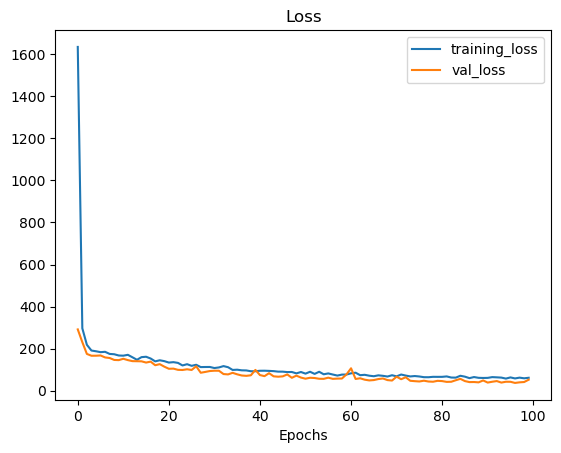

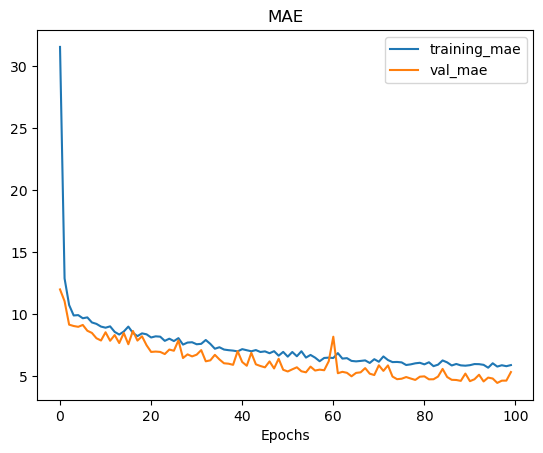

In [336]:
plot_loss_curves(history_result)

In [72]:
model_result.save("model.keras")

In [342]:
np.average(mae_result)

7.390881614685059

In [76]:
new_model = tf.keras.models.load_model('model.keras')